# Fake vs Real Image Detection —

Ensemble of EfficientNetB4, ResNet50,
Xception.

In [ ]:
import os
import random
import numpy as np
import torch

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---- Device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

# ---- Data paths (LOCAL — update these to match where you downloaded the dataset) ----
DATA_ROOT      = r"C:\Fake v real\DATA"
TRAIN_DIR      = os.path.join(DATA_ROOT, "train")   # -> C:\Fake v real\DATA\train (fake/, real/)
TEST_DIR       = os.path.join(DATA_ROOT, "valid")   # -> C:\Fake v real\DATA\valid (fake/, real/)
MODEL_SAVE_DIR = os.path.join(DATA_ROOT, "saved_models")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ---- Image / training settings ----
IMAGE_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT  = 0.2

NUM_EPOCHS_PHASE1 = 8
NUM_EPOCHS_PHASE2 = 15
LR_PHASE1 = 1e-3
LR_PHASE2 = 1e-5

CLASSES = ["fake", "real"]

print("Train path exists :", os.path.exists(TRAIN_DIR))
print("Test path exists  :", os.path.exists(TEST_DIR))

Using device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU
Train path exists : True
Test path exists  : True


## Class balance check
Same check as before — confirm fake/real split before training.

In [2]:
for split_dir, split_name in [(TRAIN_DIR, "train"), (TEST_DIR, "valid")]:
    print(f"--- {split_name} ---")
    for cls in CLASSES:
        cls_path = os.path.join(split_dir, cls)
        if os.path.exists(cls_path):
            n = len(os.listdir(cls_path))
            print(f"  {cls:6s}: {n} images")
    print()

--- train ---
  fake  : 3490 images
  real  : 3500 images

--- valid ---
  fake  : 1500 images
  real  : 1495 images



## Data loading


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),   # ~ zoom_range
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
print("Class to index mapping:", full_train_dataset.class_to_idx)

val_size = int(len(full_train_dataset) * VAL_SPLIT)
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

# validation should NOT use train-time augmentation
val_dataset.dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)

test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Train samples      : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Test samples       : {len(test_dataset)}")

Class to index mapping: {'fake': 0, 'real': 1}
Train samples      : 5592
Validation samples : 1398
Test samples       : 2995


## Models
`timm` gives pretrained EfficientNetB4, ResNet50, and Xception with a
single API. Each is built with `num_classes=1` so the head directly
outputs a single logit (binary classification via `BCEWithLogitsLoss`,
equivalent to a Dense(1, sigmoid) + binary_crossentropy in Keras, just
without a manual sigmoid — more numerically stable).

In [4]:
import sys
!{sys.executable} -m pip install timm gradio
import timm
import torch.nn as nn

def build_model(backbone_name):
    model = timm.create_model(backbone_name, pretrained=True, num_classes=1)
    # Freeze backbone, keep classifier head trainable
    for name, param in model.named_parameters():
        if "classifier" not in name and "fc" not in name and "head" not in name:
            param.requires_grad = False
    return model.to(device)

BACKBONES = {
    "EfficientNetB4": "efficientnet_b4",
    "ResNet50":       "resnet50",
    "Xception":       "xception",
}

models = {name: build_model(timm_name) for name, timm_name in BACKBONES.items()}

for name, model in models.items():
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name:15s} total: {total_params:,}  trainable (phase 1): {trainable_params:,}")

model.safetensors: reconstructing file:   0%|          |  0.00B / 77.9MB            

model.safetensors: downloading bytes:           |  0.00B            

c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LOQ\.cache\huggingface\hub\models--timm--efficientnet_b4.ra2_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LOQ\.cache\huggingface\hub\models--timm--resnet50.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model 

EfficientNetB4  total: 17,550,409  trainable (phase 1): 804,609
ResNet50        total: 23,510,081  trainable (phase 1): 2,049
Xception        total: 20,809,001  trainable (phase 1): 2,049


## Training loop


In [5]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def unfreeze_last_layers(model, n_params_groups=30):
    # Unfreeze the last N parameter tensors (roughly analogous to
    # Keras's layers[-30:]), skipping BatchNorm params
    params = list(model.named_parameters())
    to_unfreeze = params[-n_params_groups:]
    for name, param in to_unfreeze:
        if "bn" not in name.lower() and "batchnorm" not in name.lower():
            param.requires_grad = True


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(imgs)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    return total_loss / total, correct / total


def train_model(model, model_name, train_loader, val_loader):
    print(f"\n{'='*50}")
    print(f"  Training {model_name}")
    print(f"{'='*50}")

    criterion = nn.BCEWithLogitsLoss()
    history = {"phase1": {"loss": [], "val_loss": [], "acc": [], "val_acc": []},
               "phase2": {"loss": [], "val_loss": [], "acc": [], "val_acc": []}}

    # ---- Phase 1: head only ----
    print("\n-- Phase 1: Training head only --")
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_PHASE1)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

    best_val_loss, patience_counter, best_state = float("inf"), 0, None
    for epoch in range(NUM_EPOCHS_PHASE1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)

        history["phase1"]["loss"].append(train_loss)
        history["phase1"]["val_loss"].append(val_loss)
        history["phase1"]["acc"].append(train_acc)
        history["phase1"]["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS_PHASE1} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss, best_state, patience_counter = val_loss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print("Early stopping (phase 1)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # ---- Phase 2: fine-tune ----
    print("\n-- Phase 2: Fine-tuning top layers --")
    unfreeze_last_layers(model)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_PHASE2)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

    best_val_loss, patience_counter, best_state = float("inf"), 0, None
    for epoch in range(NUM_EPOCHS_PHASE2):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)

        history["phase2"]["loss"].append(train_loss)
        history["phase2"]["val_loss"].append(val_loss)
        history["phase2"]["acc"].append(train_acc)
        history["phase2"]["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS_PHASE2} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss, best_state, patience_counter = val_loss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print("Early stopping (phase 2)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(model.state_dict(), os.path.join(MODEL_SAVE_DIR, f"{model_name}.pt"))
    print(f"\n{model_name} training complete and saved!")
    return model, history


trained_models, histories = {}, {}
for model_name, model in models.items():
    trained_model, hist = train_model(model, model_name, train_loader, val_loader)
    trained_models[model_name] = trained_model
    histories[model_name] = hist

print("\nAll 3 models trained and saved successfully!")


  Training EfficientNetB4

-- Phase 1: Training head only --
Epoch 1/8 - loss: 0.7622 - acc: 0.7160 - val_loss: 0.5984 - val_acc: 0.7840
Epoch 2/8 - loss: 0.5168 - acc: 0.7899 - val_loss: 0.4784 - val_acc: 0.7997
Epoch 3/8 - loss: 0.4462 - acc: 0.8228 - val_loss: 0.4246 - val_acc: 0.8326
Epoch 4/8 - loss: 0.3796 - acc: 0.8403 - val_loss: 0.4144 - val_acc: 0.8333
Epoch 5/8 - loss: 0.3465 - acc: 0.8571 - val_loss: 0.3980 - val_acc: 0.8448
Epoch 6/8 - loss: 0.3267 - acc: 0.8732 - val_loss: 0.3598 - val_acc: 0.8619
Epoch 7/8 - loss: 0.2943 - acc: 0.8773 - val_loss: 0.3819 - val_acc: 0.8555
Epoch 8/8 - loss: 0.2647 - acc: 0.8929 - val_loss: 0.3373 - val_acc: 0.8641

-- Phase 2: Fine-tuning top layers --
Epoch 1/15 - loss: 0.2285 - acc: 0.9072 - val_loss: 0.3461 - val_acc: 0.8662
Epoch 2/15 - loss: 0.2148 - acc: 0.9111 - val_loss: 0.3314 - val_acc: 0.8670
Epoch 3/15 - loss: 0.2208 - acc: 0.9075 - val_loss: 0.3179 - val_acc: 0.8727
Epoch 4/15 - loss: 0.2013 - acc: 0.9185 - val_loss: 0.3212 -

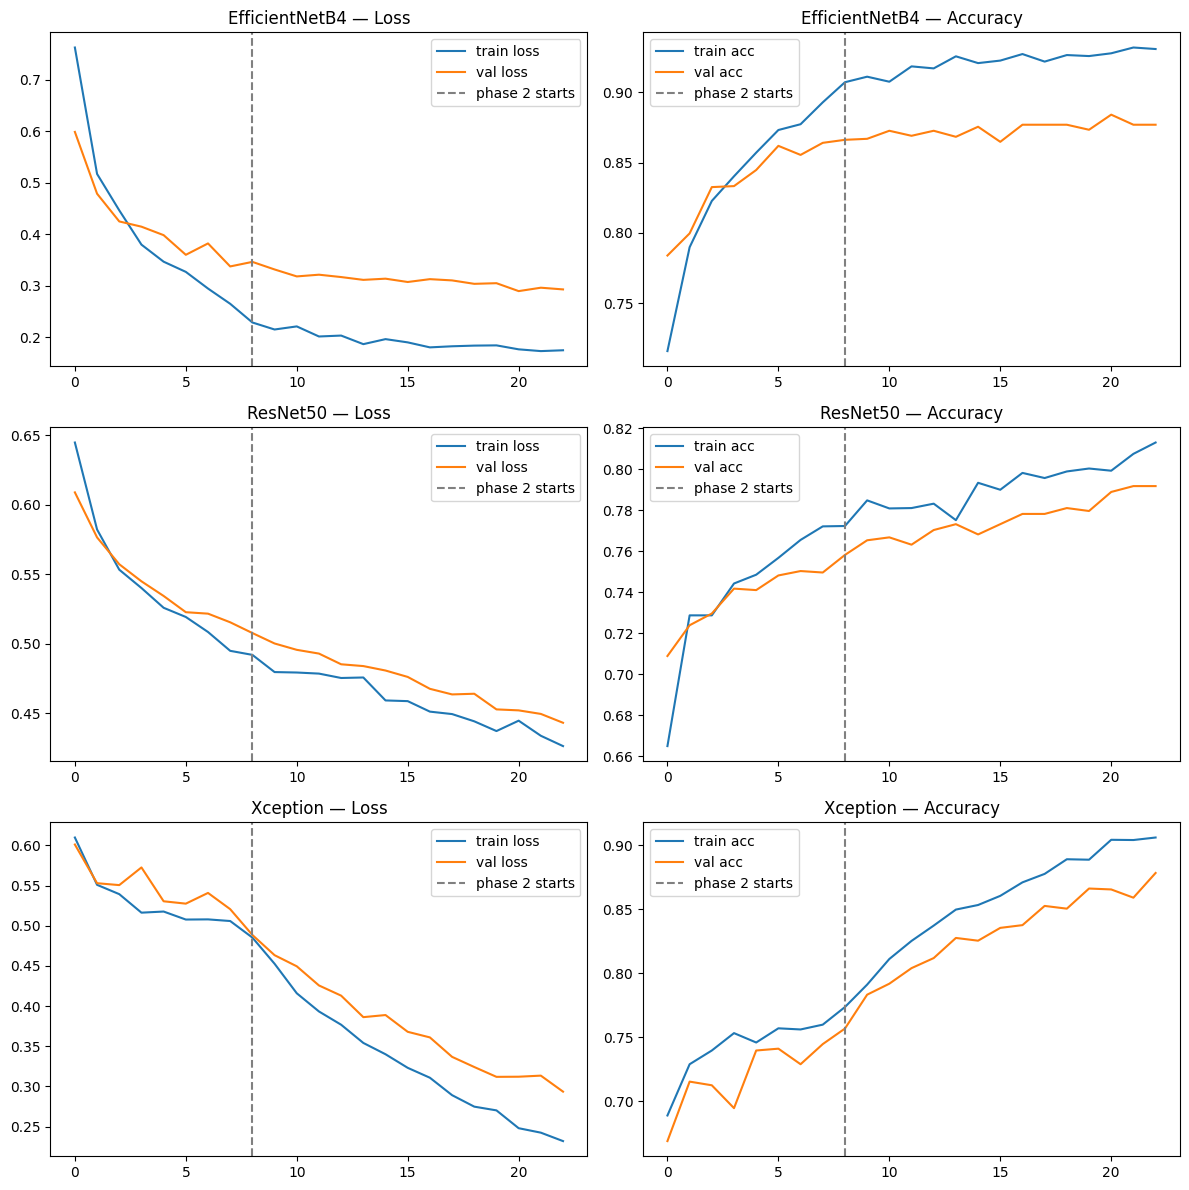

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, (model_name, hist) in enumerate(histories.items()):
    full_loss     = hist["phase1"]["loss"]     + hist["phase2"]["loss"]
    full_val_loss = hist["phase1"]["val_loss"] + hist["phase2"]["val_loss"]
    full_acc      = hist["phase1"]["acc"]      + hist["phase2"]["acc"]
    full_val_acc  = hist["phase1"]["val_acc"]  + hist["phase2"]["val_acc"]
    phase_split   = len(hist["phase1"]["loss"])

    axes[i, 0].plot(full_loss, label="train loss")
    axes[i, 0].plot(full_val_loss, label="val loss")
    axes[i, 0].axvline(phase_split, color="gray", linestyle="--", label="phase 2 starts")
    axes[i, 0].set_title(f"{model_name} — Loss")
    axes[i, 0].legend()

    axes[i, 1].plot(full_acc, label="train acc")
    axes[i, 1].plot(full_val_acc, label="val acc")
    axes[i, 1].axvline(phase_split, color="gray", linestyle="--", label="phase 2 starts")
    axes[i, 1].set_title(f"{model_name} — Accuracy")
    axes[i, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "training_curves.png"), dpi=120)
plt.show()

## Evaluation


In [7]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns

@torch.no_grad()
def get_probs_and_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

# ---- Validation predictions (for weights + threshold) ----
val_preds, val_true = {}, None
for name, model in trained_models.items():
    probs, labels = get_probs_and_labels(model, val_loader)
    val_preds[name] = probs
    val_true = labels

val_aucs = {name: roc_auc_score(val_true, p) for name, p in val_preds.items()}
print("Validation AUC per model:", val_aucs)

total_auc = sum(val_aucs.values())
weights = {name: auc / total_auc for name, auc in val_aucs.items()}
print("Ensemble weights (by val AUC):", weights)

val_ensemble = sum(weights[name] * val_preds[name] for name in weights)

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.30, 0.71, 0.01):
    f1 = f1_score(val_true, (val_ensemble > t).astype(int))
    if f1 > best_f1:
        best_f1, best_thresh = f1, t
print(f"Best threshold on validation set: {best_thresh:.2f} (val F1={best_f1:.4f})")

Validation AUC per model: {'EfficientNetB4': 0.9527041274871688, 'ResNet50': 0.8806670802138161, 'Xception': 0.9485604669397716}
Ensemble weights (by val AUC): {'EfficientNetB4': 0.34246136818230655, 'ResNet50': 0.31656675404421664, 'Xception': 0.34097187777347676}
Best threshold on validation set: 0.57 (val F1=0.9090)


         MODEL EVALUATION RESULTS

EfficientNetB4
  Accuracy : 87.15%
  F1 Score : 0.8719
  AUC-ROC  : 0.9451

ResNet50
  Accuracy : 79.27%
  F1 Score : 0.8038
  AUC-ROC  : 0.8824

Xception
  Accuracy : 86.98%
  F1 Score : 0.8725
  AUC-ROC  : 0.9461

ENSEMBLE (weighted)
  Accuracy : 90.52%
  F1 Score : 0.9033
  AUC-ROC  : 0.9664

Classification report — weighted ensemble
              precision    recall  f1-score   support

        fake       0.89      0.92      0.91      1500
        real       0.92      0.89      0.90      1495

    accuracy                           0.91      2995
   macro avg       0.91      0.91      0.91      2995
weighted avg       0.91      0.91      0.91      2995



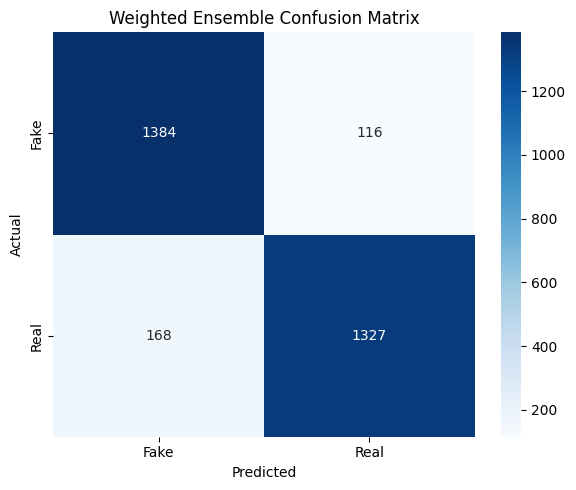

In [8]:
# ---- Test set predictions ----
test_preds, true_labels = {}, None
for name, model in trained_models.items():
    probs, labels = get_probs_and_labels(model, test_loader)
    test_preds[name] = probs
    true_labels = labels

pred_ensemble = sum(weights[name] * test_preds[name] for name in weights)
pred_ensemble_labels = (pred_ensemble > best_thresh).astype(int)

print("="*50)
print("         MODEL EVALUATION RESULTS")
print("="*50)

for name, probs in list(test_preds.items()) + [("ENSEMBLE (weighted)", pred_ensemble)]:
    labels_pred = (probs > 0.5).astype(int) if name != "ENSEMBLE (weighted)" else pred_ensemble_labels
    acc = accuracy_score(true_labels, labels_pred)
    f1  = f1_score(true_labels, labels_pred)
    auc = roc_auc_score(true_labels, probs)
    print(f"\n{name}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")

print("\n" + "="*50)
print("Classification report — weighted ensemble")
print("="*50)
print(classification_report(true_labels, pred_ensemble_labels, target_names=CLASSES))

cm = confusion_matrix(true_labels, pred_ensemble_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.title("Weighted Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [9]:
import json

ensemble_config = {"weights": weights, "threshold": float(best_thresh)}
with open(os.path.join(MODEL_SAVE_DIR, "ensemble_config.json"), "w") as f:
    json.dump(ensemble_config, f, indent=2)

print("Saved ensemble config:", ensemble_config)

Saved ensemble config: {'weights': {'EfficientNetB4': 0.34246136818230655, 'ResNet50': 0.31656675404421664, 'Xception': 0.34097187777347676}, 'threshold': 0.5700000000000003}


## Gradio demo


In [10]:
import gradio as gr
from PIL import Image

demo_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

@torch.no_grad()
def predict_image(img):
    img_t = demo_transform(img.convert("RGB")).unsqueeze(0).to(device)

    probs = {}
    for name, model in trained_models.items():
        model.eval()
        logit = model(img_t)
        probs[name] = torch.sigmoid(logit).item()

    pred = sum(weights[name] * probs[name] for name in weights)
    label = "REAL" if pred > best_thresh else "FAKE"
    confidence = pred if pred > best_thresh else 1 - pred

    result = f"""
    FINAL RESULT : {label}
    Confidence   : {confidence*100:.2f}%

    --- Per-model probability (real) ---
    EfficientNetB4 : {probs['EfficientNetB4']*100:.2f}%
    ResNet50       : {probs['ResNet50']*100:.2f}%
    Xception       : {probs['Xception']*100:.2f}%

    Weighted ensemble probability (real) : {pred*100:.2f}%
    Decision threshold                   : {best_thresh:.2f}
    """
    return result

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Textbox(label="Prediction Result", lines=12),
    title="Fake vs Real Image Detector (PyTorch, Weighted Ensemble)",
    description="Upload an image — EfficientNetB4, ResNet50 and Xception vote, weighted by validation AUC."
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f52fd6310048093469.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\uvicorn\protocols\http\h11_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\uvicorn\middleware\proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\fastapi\applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\starlette\applications.py", line 90, in __call__
    await self.middleware_stack(scope, receive, send)
  File "c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\starlette\middleware\errors.py", line 186, in __call__
    raise exc
  File "c:\Users\LOQ\.conda\env